# 05 — Ambiguity flagship and interpretive meta-tokens

The frozen 120-item ambiguity set contains 30 lexical, 30 PP-attachment, 30 garden-path, and 30 pronoun cases. Each item has original and mirrored forced-choice probes. Commitment is defined by the mean counterbalanced clean margin without using a gold label or any intervention result. The confirmatory P3 direction is raw $W_UJ$: clean-clamped coordinate swap must flip the committed reading, and internal ablation damage must exceed final concept-token suppression. Abstract English/Chinese meta-tokens are frozen before model outputs and analyzed diagnostically. Their READ estimator is the independent mean absolute $\nabla M\cdot v$ projection; WRITE×READ products remain first-order diagnostics only.

In [1]:
import json
import os
from pathlib import Path

ROOT = Path('/home/jovyan/j-space-thoughts')
os.chdir(ROOT)
os.environ['PIP_USER'] = 'false'
os.environ['PYTHONNOUSERSITE'] = '1'
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
metrics_path = ROOT / 'results/metrics.json'
spec_path = ROOT / 'data/specs/ambiguity.json'
spec = json.loads(spec_path.read_text())
print('Frozen ambiguity items:', len(spec['items']))
print('Categories:', {category: sum(item['category'] == category for item in spec['items']) for category in sorted({item['category'] for item in spec['items']})})

Frozen ambiguity items: 120
Categories: {'ambiguous_pronoun': 30, 'garden_path': 30, 'lexical_ambiguity': 30, 'pp_attachment': 30}


In [2]:
from src.ambiguity_phase import run_qwen_ambiguity_phase

ambiguity = run_qwen_ambiguity_phase(
    spec_path=spec_path,
    output_path=ROOT / 'data/raw/05_ambiguity_qwen7b.json',
    figure_path=ROOT / 'results/figures/f8_ambiguity_write_read.png',
    device='cuda',
    direction_compute_device='cuda',
    max_length=256,
    output_top_k=10,
    lens_top_k=10,
    max_swap_condition=1e4,
    tie_tolerance=0.0,
    n_bootstrap=5000,
    fail_fast=False,
)
assert ambiguity['n_frozen_items'] == 120
print('Status counts:', ambiguity['p3']['status_counts'])

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

/opt/conda/lib/python3.11/site-packages/torch/autograd/graph.py:825: UserWarning: Flash Attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at ../aten/src/ATen/native/transformers/cuda/attention_backward.cu:102.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Status counts: {'OK': 120}


## Curated metrics versus raw audit trail

`data/raw/05_ambiguity_qwen7b.json` keeps every clean variant, per-layer/per-position WRITE and READ array, token rank, and intervention record. `results/metrics.json` keeps every item's counterbalanced WRITE, independent READ, real ablation/swap/suppression effects, meta-token aggregates, commitment, control rejection, and failure status, while omitting only the repetitive raw variant tensors.

In [3]:
from src.metrics import save_json

base_keys = ('row_index', 'id', 'category', 'sentence', 'readings', 'concepts', 'workspace_layers', 'direction_method', 'direction_policy', 'measurement_status', 'commitment', 'direction_pair', 'rms_gain_fold_sensitivity')
slim_rows = []
for row in ambiguity['rows']:
    slim = {key: row[key] for key in base_keys if key in row}
    if 'counterbalanced' in row:
        slim['counterbalanced'] = row['counterbalanced']
    if 'meta_counterbalanced' in row:
        slim['meta_counterbalanced'] = row['meta_counterbalanced']
    for key in ('control_rejections', 'error_type', 'error'):
        if key in row:
            slim[key] = row[key]
    slim_rows.append(slim)
curated = {key: ambiguity[key] for key in ('schema_version', 'seed', 'model', 'lens', 'spec_path', 'n_frozen_items', 'workspace_layers', 'direction_policy', 'direction_sensitivity', 'meta_token_preregistration', 'p3', 'meta_token_diagnostics', 'figures', 'run_configuration')}
curated['rows'] = slim_rows
metrics = json.loads(metrics_path.read_text())
metrics.setdefault('ambiguity', {})['qwen2.5-7b-instruct'] = curated
save_json(metrics_path, metrics)
print('Curated ambiguity merged; metrics size MiB:', metrics_path.stat().st_size / 2**20)

Curated ambiguity merged; metrics size MiB: 23.021512985229492


In [4]:
import pandas as pd

p3 = ambiguity['p3']
overall = p3['overall']['statistics']
display(pd.DataFrame([{
    'quantity': key,
    'estimate': value.get('estimate'),
    'ci_low': value.get('ci_low'),
    'ci_high': value.get('ci_high'),
    'status': value['status'],
} for key, value in overall.items()]))
display(pd.DataFrame([{
    'category': category,
    'n_measured': result['n'],
    'swap_flip_rate': result['statistics']['swap_flip_rate'].get('estimate'),
    'damage_gap': result['statistics']['internal_minus_suppression_damage'].get('estimate'),
} for category, result in p3['by_category'].items()]))
print('P3 verdict:', p3['verdict'])
print('Verdict rule:', p3['verdict_rule'])

,quantity,estimate,ci_low,ci_high,status
0,clean_committed_margin,9.160937,8.294766,10.030208,ESTIMATED
1,swap_edited_committed_margin,8.438802,7.598932,9.285208,ESTIMATED
2,swap_flip_rate,0.033333,0.008333,0.066667,ESTIMATED
3,internal_ablation_positive_damage,1.151302,0.956504,1.362507,ESTIMATED
4,output_suppression_positive_damage,0.000000,0.000000,0.000000,ESTIMATED
5,internal_minus_suppression_damage,1.151302,0.950508,1.359642,ESTIMATED
6,ablation_exceeds_suppression_rate,0.825000,0.750000,0.891667,ESTIMATED
7,counterbalance_agreement_rate,0.841667,0.775000,0.900000,ESTIMATED


,category,n_measured,swap_flip_rate,damage_gap
0,ambiguous_pronoun,30,0.033333,1.577083
1,garden_path,30,0.033333,0.586458
2,lexical_ambiguity,30,0.033333,0.985417
3,pp_attachment,30,0.033333,1.456250


P3 verdict: refuted
Verdict rule: supported iff the 95% CI lower bound for swap-flip rate exceeds 0.5 and the CI lower bound for the damage gap exceeds 0; mixed iff both point criteria hold; otherwise refuted


In [5]:
meta = ambiguity['meta_token_diagnostics']
display(pd.DataFrame([{
    'candidate': key,
    'language': result['candidate']['language'],
    'n': result['n_complete_items'],
    'WRITE': result['mean_abs_write'].get('estimate'),
    'READ': result['mean_independent_read_abs'].get('estimate'),
    'ablation_damage': result['mean_ablation_positive_damage'].get('estimate'),
    'corr_damage_READ': result['read_vs_ablation_damage'].get('estimate'),
    'partial_damage_READ_given_WRITE': result['partial_causal_read_given_write'].get('estimate'),
} for key, result in meta['by_candidate'].items()]))
print(meta['interpretation_warning'])

,candidate,language,n,WRITE,READ,ablation_damage,corr_damage_READ,partial_damage_READ_given_WRITE
0,interpretation_en,en,120,6.197022,0.013798,1.113542,0.018696,0.018669
1,meaning_en,en,120,3.620158,0.010679,0.149479,-0.002685,-0.010686
2,ambiguous_en,en,120,8.331267,0.014400,1.289583,0.109784,0.110035
3,ambiguity_en,en,120,9.586675,0.016062,1.472396,0.159040,0.159126
4,explain_zh,zh,120,8.824749,0.013975,0.187760,-0.167593,-0.168102
5,meaning_formal_zh,zh,120,11.225990,0.016102,1.496875,0.211382,0.216067
6,meaning_colloquial_zh,zh,120,9.494662,0.014896,0.938542,0.196204,0.197921
7,vague_zh,zh,120,12.059813,0.015879,1.799479,0.160966,0.166878
8,interpret_zh,zh,120,10.497933,0.014772,0.685677,-0.050074,-0.050131


These predeclared meta-token results are descriptive diagnostics. No candidate is selected or promoted based on WRITE, rank, or ablation outcomes, and they are not part of the confirmatory P3 verdict.


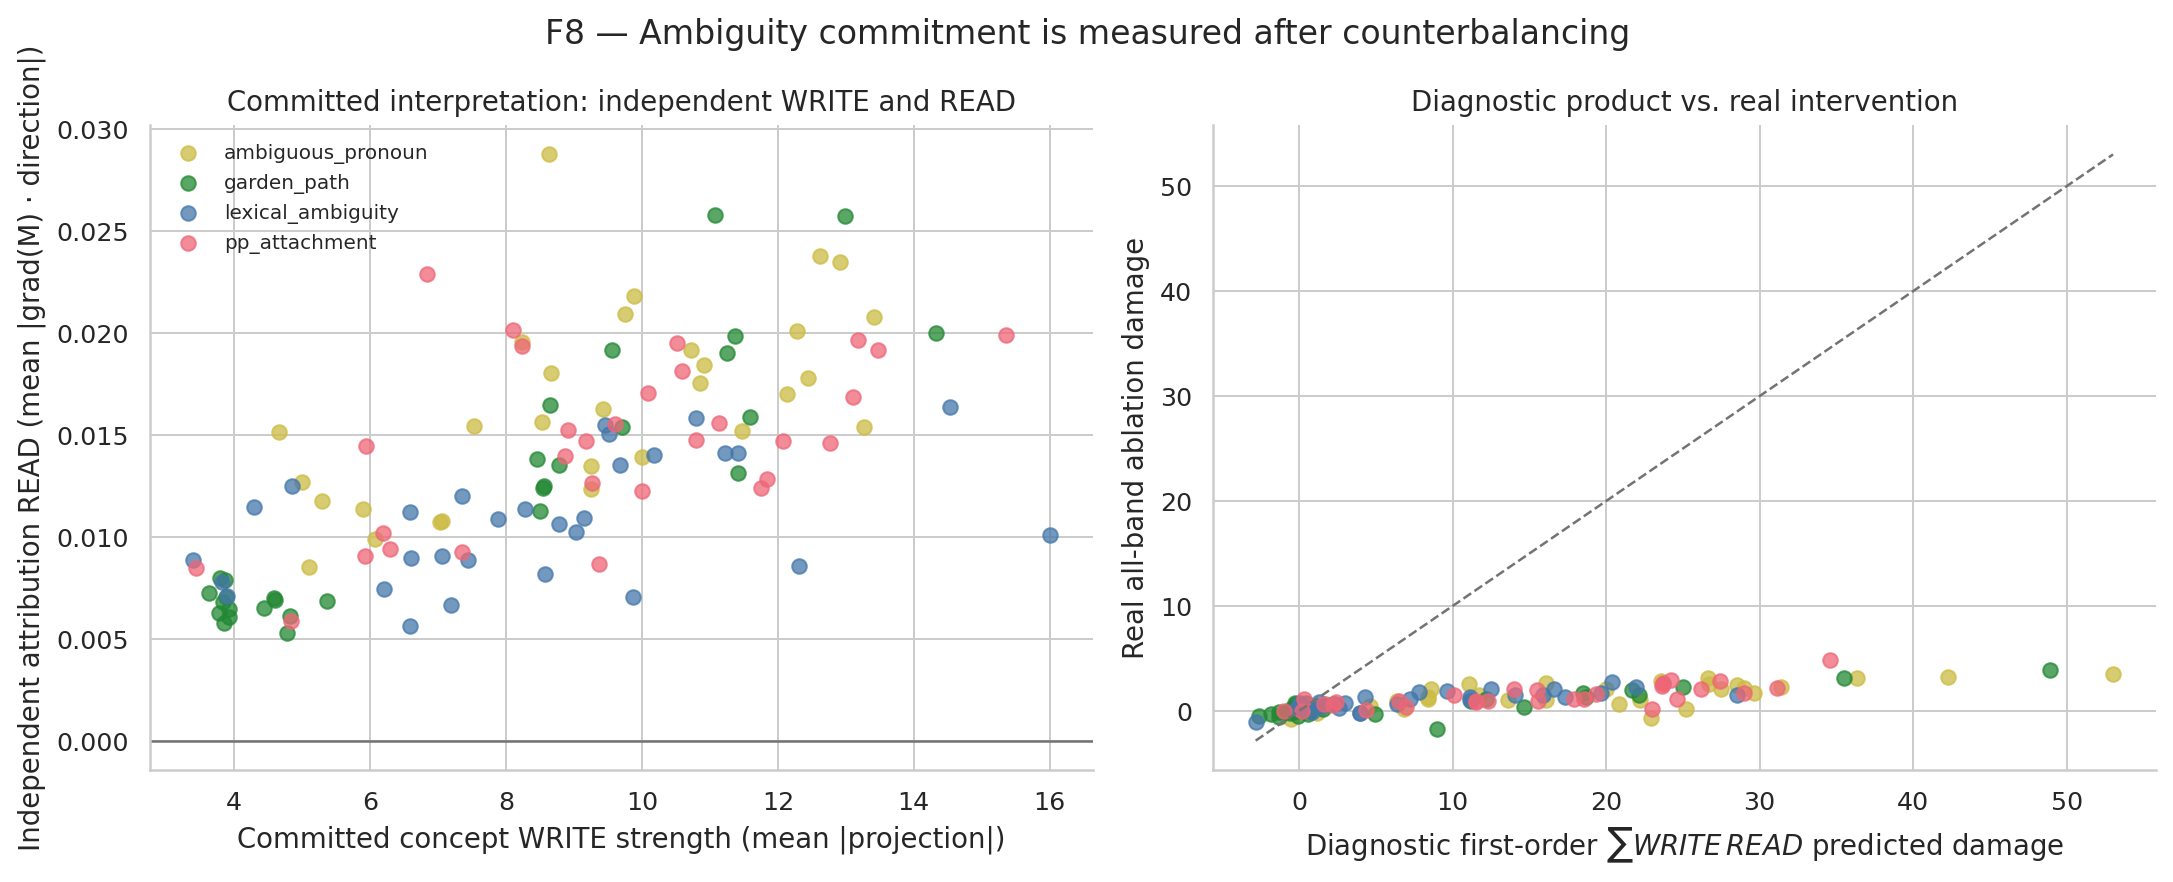

In [6]:
from IPython.display import Image, display

display(Image(filename=ambiguity['figures']['f8']))

In [7]:
print('PHASE 05 COMPUTED')
print('P3', ambiguity['p3']['verdict'].upper())
print('Frozen/measured/status:', ambiguity['n_frozen_items'], ambiguity['p3']['overall']['n'], ambiguity['p3']['status_counts'])
print('Ambiguity uses raw J-Lens directions only; mean-difference robustness is not established for this phase.')

PHASE 05 COMPUTED
P3 REFUTED
Frozen/measured/status: 120 120 {'OK': 120}
Ambiguity uses raw J-Lens directions only; mean-difference robustness is not established for this phase.
